In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:

subscribers = pd.read_csv("subscribers.csv")
titles = pd.read_csv("titles.csv")
watch_history = pd.read_csv("watch_history.csv")
ratings = pd.read_csv("ratings.csv")
reviews = pd.read_csv("reviews.csv")
watchlist = pd.read_csv("watchlist.csv")

1. Monthly viewing sessions trend


In [7]:
monthly_sessions = watch_history.groupby(watch_history['watch_date'].dt.to_period("M")).size()
monthly_sessions.index = monthly_sessions.index.astype(str)

monthly_sessions.plot(kind='line', figsize=(14,6), color='blue', marker='o')
plt.title("Monthly Viewing Sessions Trend")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/monthly_sessions.png")
plt.show()


AttributeError: Can only use .dt accessor with datetimelike values

Yearly viewing sessions trend

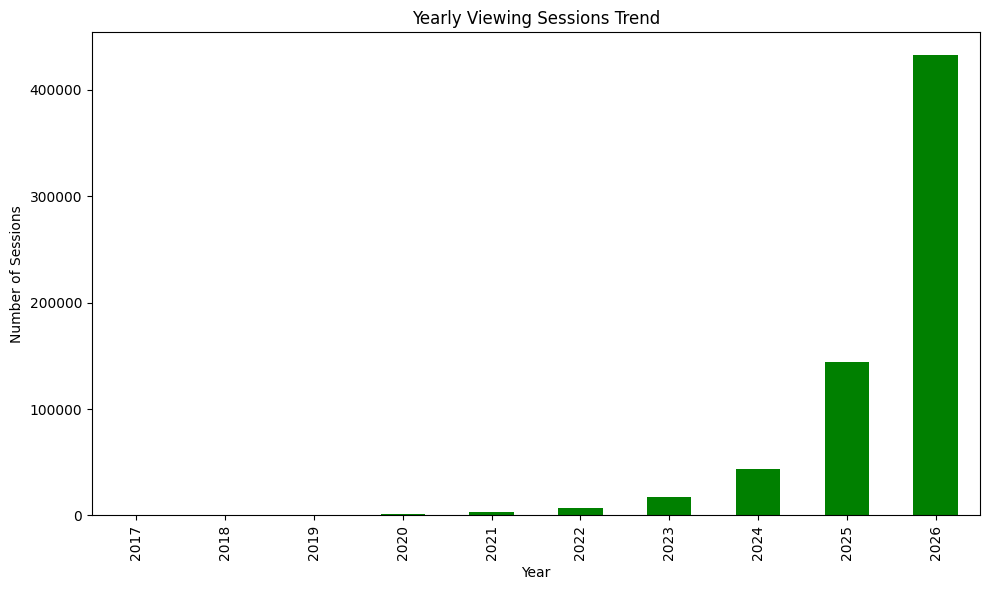

In [ ]:
yearly_sessions = watch_history.groupby(watch_history['watch_date'].dt.year).size()
yearly_sessions.plot(kind='bar', figsize=(10,6), color='green')
plt.title("Yearly Viewing Sessions Trend")
plt.xlabel("Year")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.savefig("charts/yearly_sessions.png")
plt.show()


2. Monthly watch hours trend

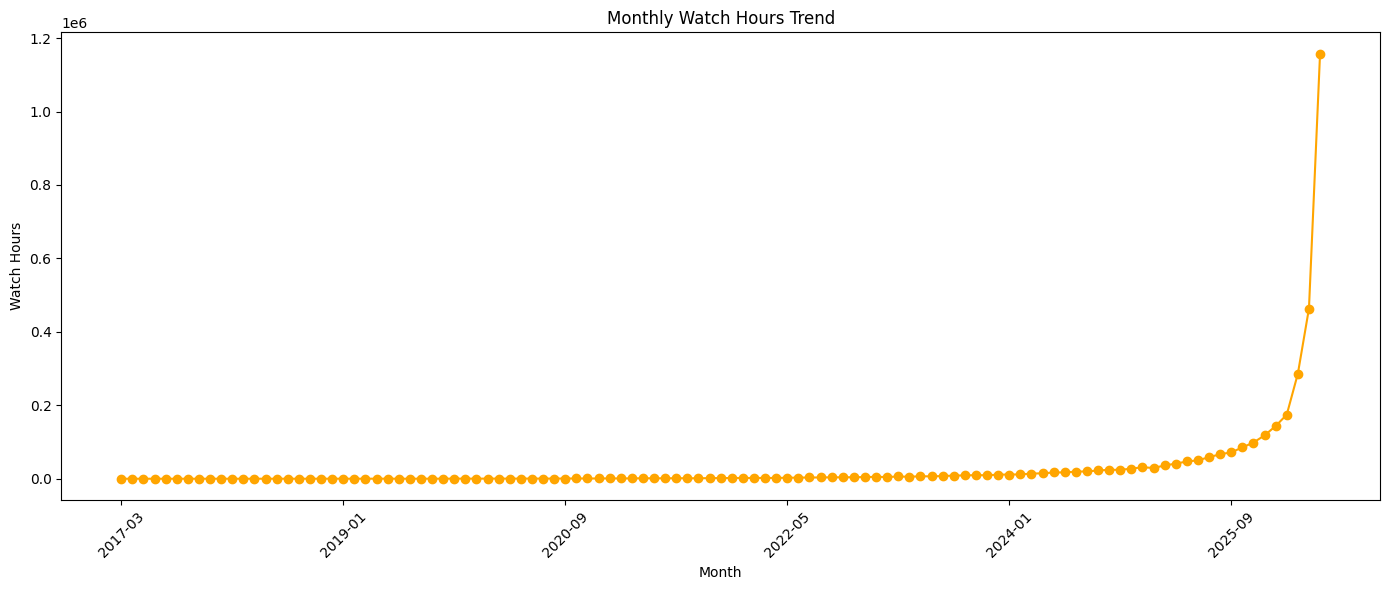

In [ ]:
monthly_hours = watch_history.groupby(watch_history['watch_date'].dt.to_period("M"))['watch_duration_min'].sum()/60
monthly_hours.index = monthly_hours.index.astype(str)

monthly_hours.plot(kind='line', figsize=(14,6), color='orange', marker='o')
plt.title("Monthly Watch Hours Trend")
plt.xlabel("Month")
plt.ylabel("Watch Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/monthly_watch_hours.png")
plt.show()


Genre-wise watch hours

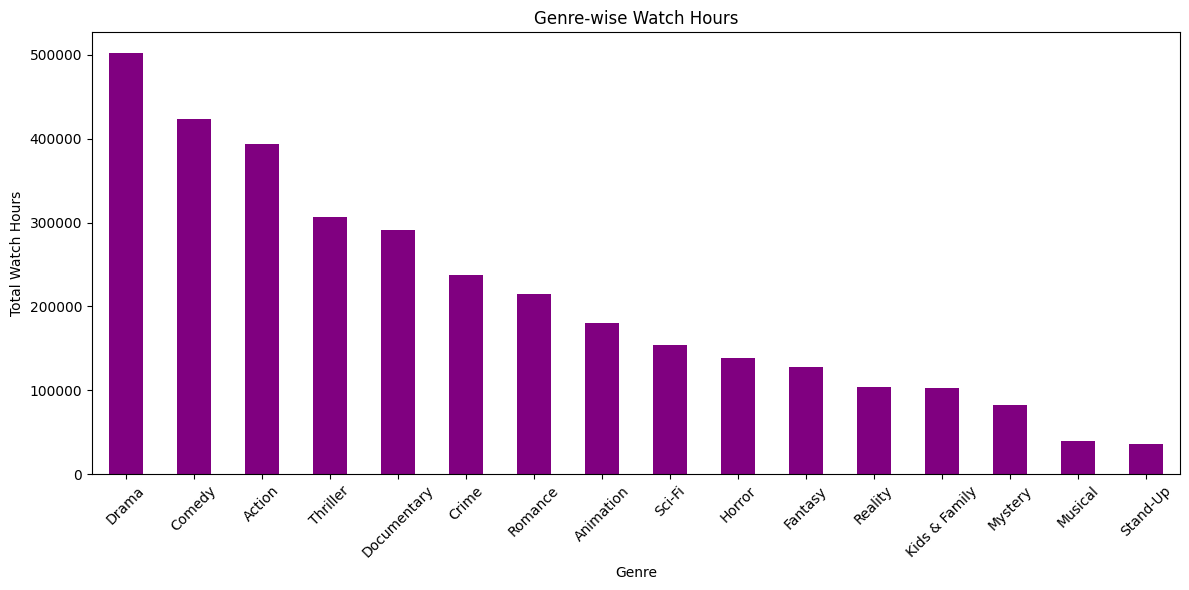

In [ ]:
genre_hours = watch_history.merge(titles, on='title_id') \
                           .groupby('primary_genre')['watch_duration_min'].sum()/60

genre_hours.sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color='purple')
plt.title("Genre-wise Watch Hours")
plt.xlabel("Genre")
plt.ylabel("Total Watch Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/genre_watch_hours.png")
plt.show()


Movies vs TV Shows (donut)

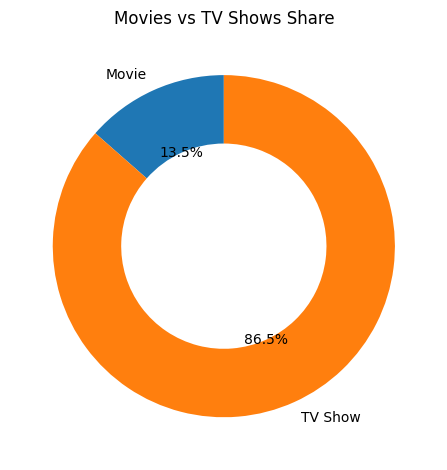

In [ ]:
type_hours = watch_history.merge(titles, on='title_id') \
                          .groupby('type')['watch_duration_min'].sum()/60

plt.pie(type_hours, labels=type_hours.index, autopct='%1.1f%%', startangle=90, wedgeprops={'width':0.4})
plt.title("Movies vs TV Shows Share")
plt.tight_layout()
plt.savefig("charts/movies_vs_tvshows.png")
plt.show()


 Top 10 countries by watch hours

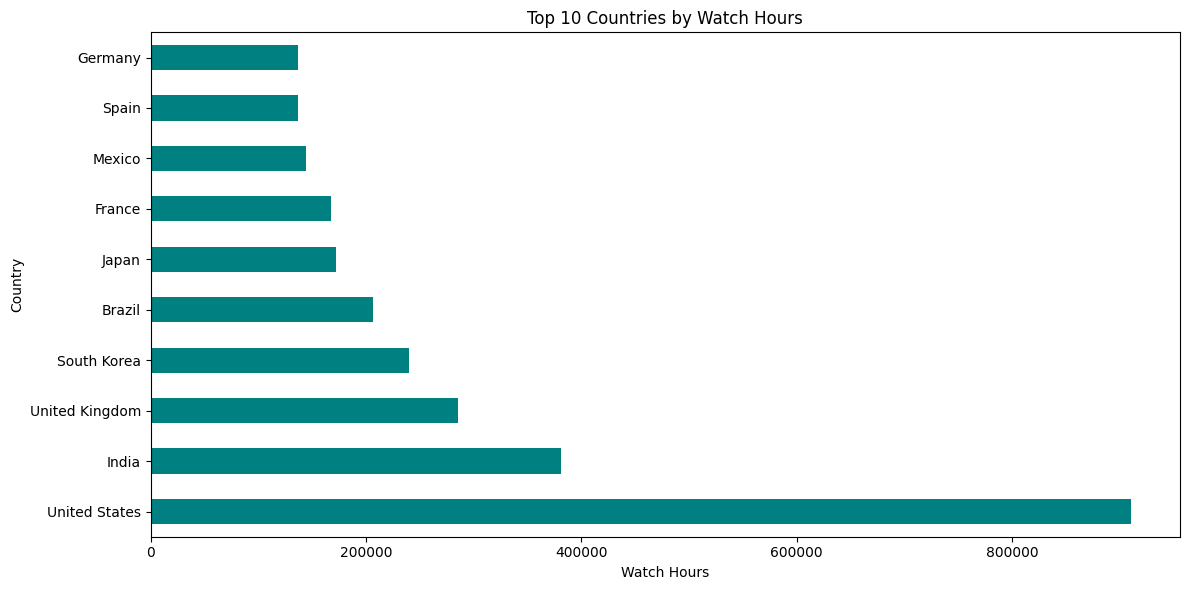

In [ ]:
country_hours = watch_history.merge(subscribers, on='subscriber_id') \
                             .groupby('country')['watch_duration_min'].sum()/60

top10_countries = country_hours.sort_values(ascending=False).head(10)

top10_countries.plot(kind='barh', figsize=(12,6), color='teal')
plt.title("Top 10 Countries by Watch Hours")
plt.xlabel("Watch Hours")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("charts/top_countries.png")
plt.show()


Subscriber plan distribution

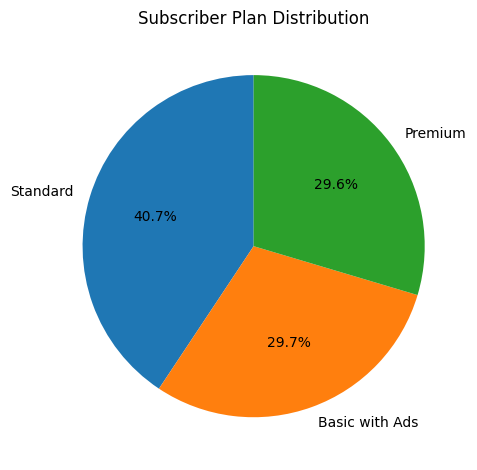

In [ ]:
plan_counts = subscribers['plan_type'].value_counts()

plt.pie(plan_counts, labels=plan_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Subscriber Plan Distribution")
plt.tight_layout()
plt.savefig("charts/plan_distribution.png")
plt.show()


Device usage

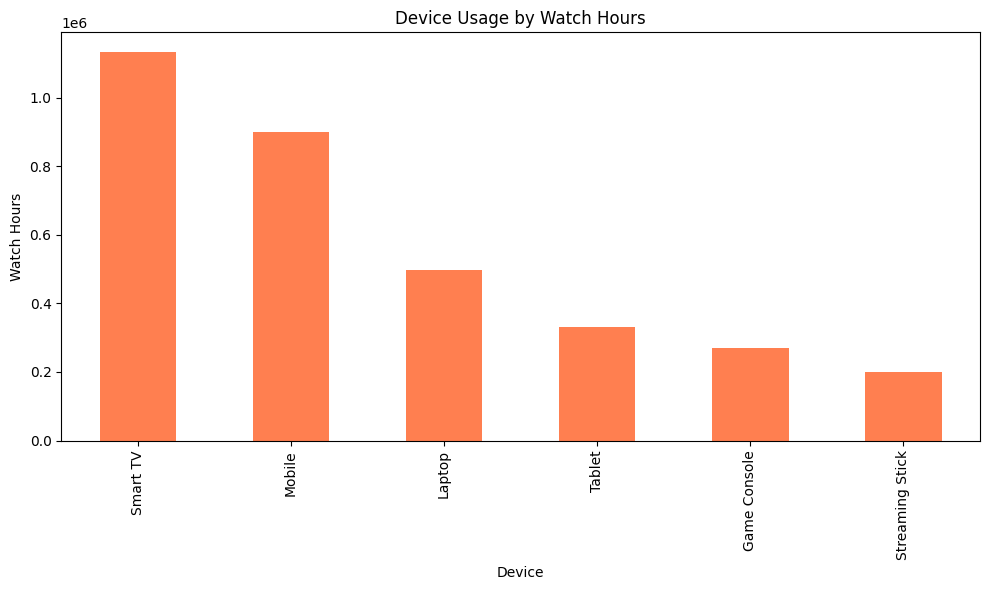

In [ ]:
device_hours = watch_history.groupby('device')['watch_duration_min'].sum()/60

device_hours.sort_values(ascending=False).plot(kind='bar', figsize=(10,6), color='coral')
plt.title("Device Usage by Watch Hours")
plt.xlabel("Device")
plt.ylabel("Watch Hours")
plt.tight_layout()
plt.savefig("charts/device_usage.png")
plt.show()


Top 10 Titles by Watch Hours

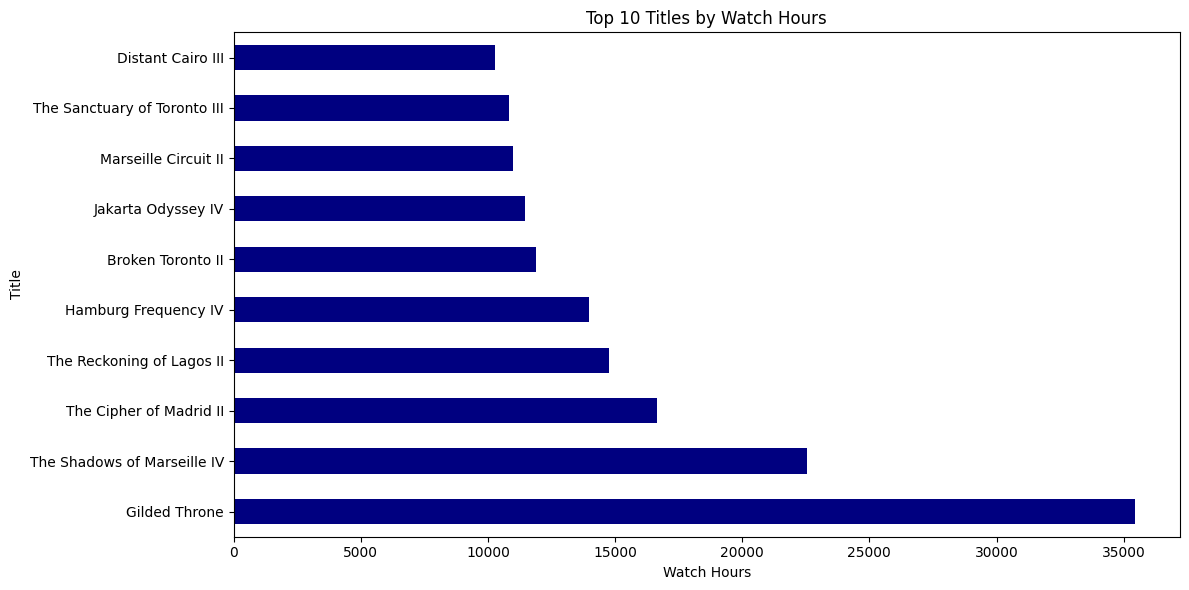

In [ ]:
title_hours = watch_history.merge(titles, on='title_id') \
                           .groupby('title_name')['watch_duration_min'].sum()/60

top10_titles = title_hours.sort_values(ascending=False).head(10)

top10_titles.plot(kind='barh', figsize=(12,6), color='navy')
plt.title("Top 10 Titles by Watch Hours")
plt.xlabel("Watch Hours")
plt.ylabel("Title")
plt.tight_layout()
plt.savefig("charts/top_titles.png")
plt.show()


 Age distribution

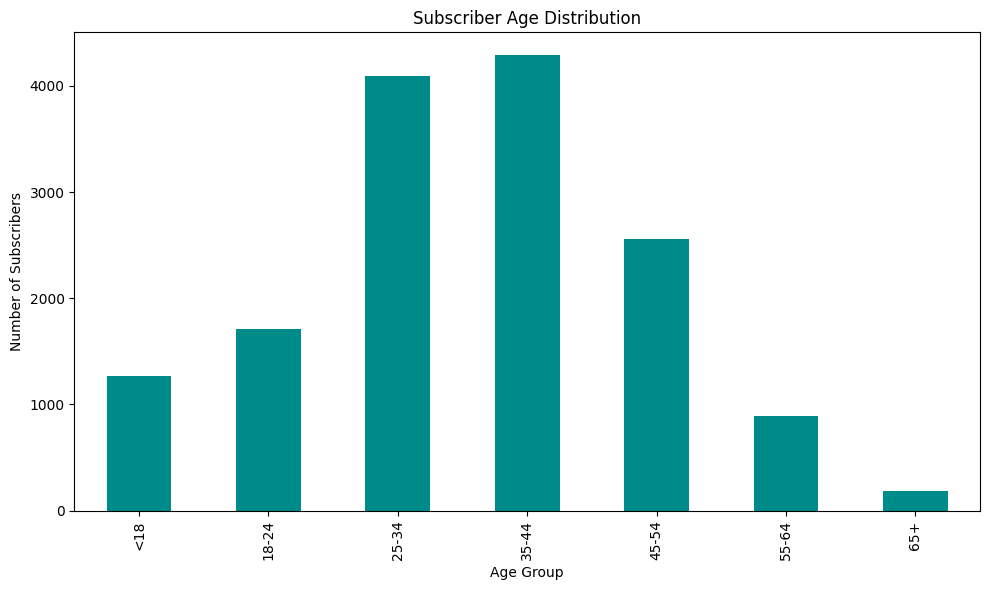

In [ ]:
age_bins = [0, 17, 24, 34, 44, 54, 64, 100]
age_labels = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

subscribers['age_group'] = pd.cut(subscribers['age'], bins=age_bins, labels=age_labels)

age_distribution = subscribers['age_group'].value_counts().sort_index()

age_distribution.plot(kind='bar', figsize=(10,6), color='darkcyan')
plt.title("Subscriber Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Subscribers")
plt.tight_layout()
plt.savefig("charts/age_distribution.png")
plt.show()


 Completion rate by genre

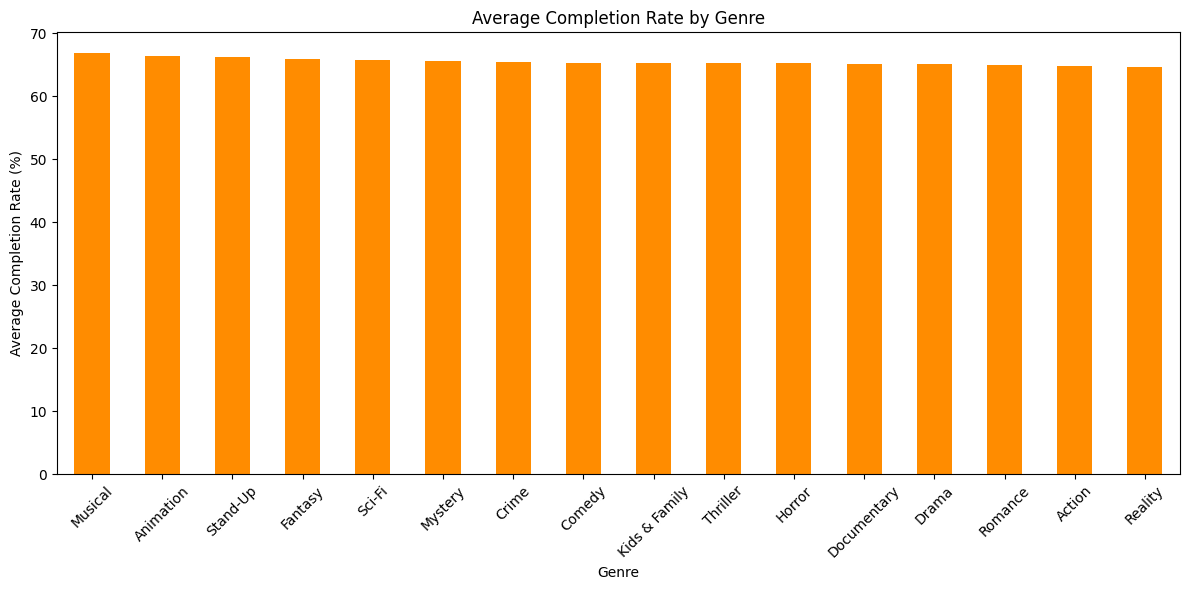

In [ ]:
# Calculate completion_pct per session
watch_history['completion_pct'] = (watch_history['watch_duration_min'] / watch_history['content_duration_min']) * 100

# Merge with titles to get genre
genre_completion = watch_history.merge(titles, on='title_id') \
                                .groupby('primary_genre')['completion_pct'].mean()

genre_completion.sort_values(ascending=False).plot(kind='bar', figsize=(12,6), color='darkorange')
plt.title("Average Completion Rate by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Completion Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/completion_by_genre.png")
plt.show()


Review sentiment breakdown

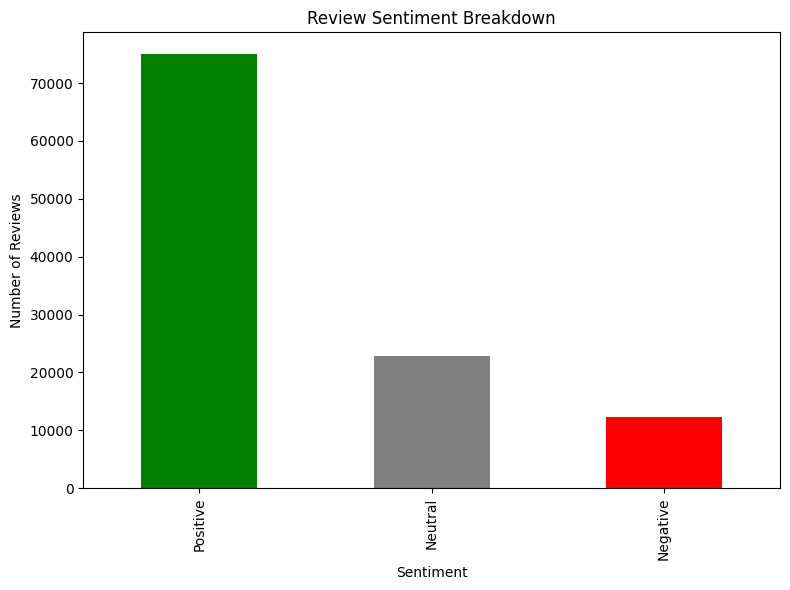

In [ ]:
sentiment_counts = reviews['sentiment'].value_counts()

sentiment_counts.plot(kind='bar', figsize=(8,6), color=['green','gray','red'])
plt.title("Review Sentiment Breakdown")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("charts/review_sentiment.png")
plt.show()
